# PAutomaC Mini Workflow (Treba + `treba_py`)

This notebook demonstrates a small, reproducible workflow on one PAutomaC problem:

1. Load `train` / `test` sequences from `pautomac_final.tar.gz`.
2. Train small PFSA and HMM models.
3. Score and decode sample test strings.

For full challenge-style evaluation and batteries, use:

- `scripts/pautomac_eval.py`
- `scripts/pautomac_battery.py`

In [1]:
from __future__ import annotations

from itertools import islice
from pathlib import Path
import sys
import tarfile

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "treba").exists() and (REPO_ROOT.parent / "treba").exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from treba_py import HMM, PFSA, TokenizationConfig, TrainingConfig, TrebaRunner

TREBA_BIN = (REPO_ROOT / "treba").resolve()
ARCHIVE = (REPO_ROOT / "pautomac_final.tar.gz").resolve()
RUNNER = TrebaRunner(str(TREBA_BIN))

print("Repo root:", REPO_ROOT)
print("Treba binary:", TREBA_BIN)
print("Archive:", ARCHIVE)

Repo root: /home/ubuntu/dev/treba
Treba binary: /home/ubuntu/dev/treba/treba
Archive: /home/ubuntu/dev/treba/pautomac_final.tar.gz


In [2]:
def read_pautomac_split(archive_path: Path, problem_id: int, split: str) -> list[list[str]]:
    """Load one split from PAutomaC tar archive as token sequences (string tokens)."""
    member_name = f"pautomac/{problem_id}.pautomac.{split}"
    with tarfile.open(archive_path, "r:gz") as tar:
        f = tar.extractfile(member_name)
        if f is None:
            raise FileNotFoundError(member_name)
        lines = f.read().decode("utf-8").splitlines()

    if not lines:
        return []

    sequences: list[list[str]] = []
    for line in lines[1:]:
        parts = line.strip().split()
        if not parts:
            continue
        length = int(parts[0])
        if length == 0:
            sequences.append([])
        else:
            sequences.append(parts[1:])
    return sequences

In [3]:
problem_id = 1
train_full = read_pautomac_split(ARCHIVE, problem_id, "train")
test_full = read_pautomac_split(ARCHIVE, problem_id, "test")

print(f"Problem {problem_id}: train={len(train_full)} test={len(test_full)}")
print("Example train sequence:", train_full[0][:10], "...")

Problem 1: train=20000 test=1000
Example train sequence: ['5', '4', '1', '1', '5', '3', '4', '7', '4', '7'] ...


Keep this notebook fast by taking small subsets.

In [4]:
train = list(islice(train_full, 300))
test = list(islice(test_full, 20))

print("Using subset sizes:", len(train), len(test))

Using subset sizes: 300 20


## PFSA example

In [5]:
pfsa = PFSA(
    n_states=5,
    training=TrainingConfig(algorithm="bw", max_iter=20),
    runner=RUNNER,
)
pfsa.fit(train)

print("PFSA scores (first 5):", pfsa.score(test[:5]))
print("PFSA decode example:", pfsa.decode([test[0]], with_prob=True)[0])

PFSA scores (first 5): [0.13502109798444065, 3.44669829540787e-10, 0.0002748971241101789, 2.8624879316602616e-08, 0.0018580596706068654]
PFSA decode example: DecodeResult(states=[0], prob=0.13502109798444065)


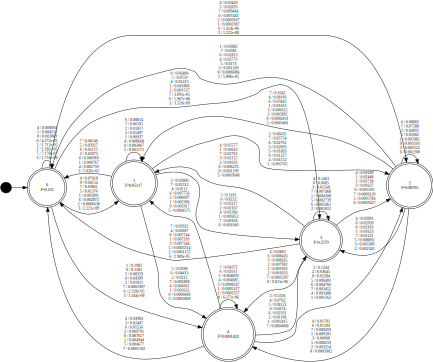

In [6]:
pfsa.draw()

## HMM example

In [7]:
hmm = HMM(
    n_states=20,
    training=TrainingConfig(algorithm="bw", max_iter=20),
    token_config=TokenizationConfig(),
    runner=RUNNER,
)
hmm.fit(train)

print("HMM scores (first 5):", hmm.score(test[:5]))
print("HMM decode example:", hmm.decode([test[0]], with_prob=True)[0])

HMM scores (first 5): [0.1399999800210612, 6.091414651216038e-10, 0.0003504596937755653, 2.367368500448584e-08, 0.003312257712892705]
HMM decode example: DecodeResult(states=[0, 19], prob=0.1399999800210612)


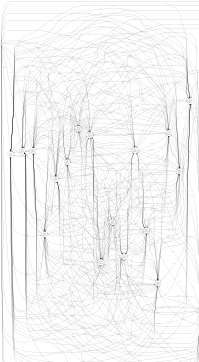

In [8]:
hmm.draw()

## Optional next steps

- Increase subset size to full train/test.
- Compare multiple algorithms (`bw`, `dabw`, `vb`, `vitbw`).
- Export trained models and evaluate with `scripts/pautomac_eval.py` for challenge-style perplexity.